In [59]:
# snippet 1 - imports & constants
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix, classification_report

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid", context="talk")

# Adjust these to match your column names exactly
COL_TIME = "Time (s)"
COL_VOLT = "Voltage (V)"
COL_TEMP = "TC1 (C)"

# Paths (change if needed)
TRAIN_DIR = r"C:\Users\Nakshatra\NL\second_year\Project_EE_299\processed_cell_files"
TEST_DIR  = r"C:\Users\Nakshatra\NL\second_year\Project_EE_299\test"


In [60]:
!pip install xgboost

In [61]:
# runs pip with the same Python as the kernel
import sys
!{sys.executable} -m pip install openpyxl


In [62]:
# snippet 2 - load files from folder into a single DataFrame (with file id)
def load_folder(folder_path):
    files = sorted(glob.glob(os.path.join(folder_path, "*.xlsx")) + glob.glob(os.path.join(folder_path, "*.xls")))
    df_list = []
    for f in files:
        try:
            tmp = pd.read_excel(f)
        except Exception as e:
            print(f"Failed reading {f}: {e}")
            continue
        tmp['_source_file'] = Path(f).name
        df_list.append(tmp)
    if not df_list:
        raise ValueError(f"No Excel files in {folder_path}")
    df = pd.concat(df_list, ignore_index=True)
    return df

df_train_raw = load_folder(TRAIN_DIR)
df_test_raw  = load_folder(TEST_DIR)

print("Training files rows:", len(df_train_raw), "Test files rows:", len(df_test_raw))


Training files rows: 14754 Test files rows: 2246


In [116]:
# Complete, fixed implementation of the improved labeling function + example usage.
# Paste & run this cell (assumes COL_TIME, COL_TEMP, COL_VOLT, df_train_raw, df_test_raw exist).

import numpy as np
import pandas as pd

# -------------------------
# Tunable parameters (edit as needed)
# -------------------------
params = {
    "rate_thresh_abs": 0.6,    # °C/s
    "z_k": 4.0,                # std multiplier
    "rolling_window": 5,
    "min_temp_C": 55.0,       # minimum temperature to consider anomaly
    "min_increase_C": 12.0,    # required future rise (°C)
    "lookahead_samples": 8,   # how many samples to look ahead
    "min_consecutive": 6,     # require this many consecutive candidate points
    "expand_forward": 8       # expand event forward by this many samples
}

# -------------------------
# Improved labeling function (fixed indentation / params)
# -------------------------
def preprocess_and_label_improved(df, label_params=None):
    """
    Improved labeling that avoids low-temp false positives and long-plateau labeling.
    Returns copy of df with new columns including 'label_final'.
    """
    if label_params is None:
        label_params = {}

    # define params (defaults overridden by label_params)
    p = {
        "rolling_window": int(label_params.get("rolling_window", params["rolling_window"])),
        "rate_thresh_abs": float(label_params.get("rate_thresh_abs", params["rate_thresh_abs"])),
        "z_k": float(label_params.get("z_k", params["z_k"])),
        "min_temp_C": float(label_params.get("min_temp_C", params["min_temp_C"])),
        "min_increase_C": float(label_params.get("min_increase_C", params["min_increase_C"])),
        "lookahead_samples": int(label_params.get("lookahead_samples", params["lookahead_samples"])),
        "min_consecutive": int(label_params.get("min_consecutive", params["min_consecutive"])),
        "expand_forward": int(label_params.get("expand_forward", params["expand_forward"]))
    }

    df = df.copy()

    # ensure sorted by file/time
    if '_source_file' in df.columns:
        df.sort_values(['_source_file', COL_TIME], inplace=True)
    else:
        df.sort_values(COL_TIME, inplace=True)

    # compute dt robustly
    group_col = '_source_file' if '_source_file' in df.columns else None
    if group_col:
        dt = df.groupby(group_col)[COL_TIME].diff()
    else:
        dt = df[COL_TIME].diff()
    dt = dt.replace(0, np.nan)
    if pd.api.types.is_datetime64_any_dtype(dt):
        dt = dt.dt.total_seconds()
    dt = dt.bfill().fillna(1.0)
    df['dt'] = dt

    # numeric columns (safe casting)
    df['temp'] = df[COL_TEMP].astype(float)
    df['voltage'] = df[COL_VOLT].astype(float)

    # derivatives
    if group_col:
        df['temp_prev'] = df.groupby(group_col)['temp'].shift(1)
        df['temp_diff'] = df['temp'] - df['temp_prev']
        df['temp_rate'] = df['temp_diff'] / df['dt']
        df['volt_prev'] = df.groupby(group_col)['voltage'].shift(1)
    else:
        df['temp_prev'] = df['temp'].shift(1)
        df['temp_diff'] = df['temp'] - df['temp_prev']
        df['temp_rate'] = df['temp_diff'] / df['dt']
        df['volt_prev'] = df['voltage'].shift(1)

    df['volt_diff'] = df['voltage'] - df['volt_prev']
    df['volt_rate'] = df['volt_diff'] / df['dt']

    # rolling stats
    rw = p["rolling_window"]
    if group_col:
        df['temp_rate_roll_mean'] = df.groupby(group_col)['temp_rate'].transform(lambda s: s.rolling(rw, min_periods=1).mean())
        df['temp_rate_roll_std']  = df.groupby(group_col)['temp_rate'].transform(lambda s: s.rolling(rw, min_periods=1).std().fillna(0))
    else:
        df['temp_rate_roll_mean'] = df['temp_rate'].rolling(rw, min_periods=1).mean()
        df['temp_rate_roll_std']  = df['temp_rate'].rolling(rw, min_periods=1).std().fillna(0)

    # base rate conditions
    cond_abs = df['temp_rate'].abs() >= p["rate_thresh_abs"]
    cond_z   = df['temp_rate'] >= (df['temp_rate_roll_mean'] + p["z_k"] * df['temp_rate_roll_std'])
    cond_rate = cond_abs | cond_z

    # lookahead future max temperature (forward window) -> compute safely per-group
    look = p["lookahead_samples"]
    if group_col:
        # compute forward rolling max by reversing series per group
        df['_future_max_temp'] = df.groupby(group_col)['temp'].transform(lambda s: s[::-1].rolling(look, min_periods=1).max()[::-1].values)
    else:
        df['_future_max_temp'] = df['temp'][::-1].rolling(look, min_periods=1).max()[::-1].values

    df['_temp_future_increase'] = df['_future_max_temp'] - df['temp']

    cond_temp_min = df['temp'] >= p["min_temp_C"]
    cond_future_increase = df['_temp_future_increase'] >= p["min_increase_C"]

    # candidate flag: rate condition AND (temp >= min_temp OR sufficient future increase)
    df['candidate'] = (cond_rate) & (cond_temp_min | cond_future_increase)

    # require consecutive candidates to avoid single-sample noise
    min_cons = p["min_consecutive"]
    if group_col:
        df['candidate_cons'] = df.groupby(group_col)['candidate'].transform(lambda s: (s.rolling(min_cons, min_periods=1).sum() >= min_cons).astype(int))
    else:
        df['candidate_cons'] = (df['candidate'].rolling(min_cons, min_periods=1).sum() >= min_cons).astype(int)

    # expand forward/backward to capture whole event (stop conditions could be added if desired)
    expand_fwd = p["expand_forward"]
    df['label_raw'] = 0
    if group_col:
        for name, g in df.groupby(group_col):
            idx = g.index
            cand_idx = idx[g['candidate_cons'].values == 1]
            labels = np.zeros(len(idx), dtype=int)
            pos_in_group = {v:i for i,v in enumerate(idx)}
            for ci in cand_idx:
                i = pos_in_group[ci]
                start = max(0, i - (min_cons-1))
                end = min(len(idx), i + expand_fwd + 1)
                labels[start:end] = 1
            df.loc[idx, 'label_raw'] = labels
    else:
        idx = df.index
        labels = np.zeros(len(df), dtype=int)
        cand_positions = np.where(df['candidate_cons'].values == 1)[0]
        for pos in cand_positions:
            start = max(0, pos - (min_cons-1))
            end = min(len(df), pos + expand_fwd + 1)
            labels[start:end] = 1
        df['label_raw'] = labels

    # final label
    df['label_final'] = df['label_raw'].astype(int)

    # keep helper columns for debugging (optional to drop)
    return df

# -------------------------
# Example usage: apply to train/test raw DFs
# (assumes df_train_raw and df_test_raw already exist in the environment)
# -------------------------
# Apply improved labeling with the tuned params defined above
df_train = preprocess_and_label_improved(df_train_raw, params)
df_test  = preprocess_and_label_improved(df_test_raw, params)

# fill NA (if desired) and quick counts
df_train = df_train.fillna(0)
df_test  = df_test.fillna(0)

print("Train positive labels:", int(df_train['label_final'].sum()),
      " Test positives:", int(df_test['label_final'].sum()))



Train positive labels: 10829  Test positives: 827


In [117]:
# Robust build X,y + scaler (handles missing rolling cols)
from sklearn.preprocessing import StandardScaler

# your desired features (keep as you had)
FEATURES = ['temp', 'temp_rate', 'temp_roll_mean', 'temp_roll_std', 'volt_rate', 'volt_diff']

# helper: ensure required columns exist in df (in-place)
def ensure_features(df, rolling_window=5):
    # compute dt if missing
    if 'dt' not in df.columns:
        if '_source_file' in df.columns:
            dt = df.groupby('_source_file')[COL_TIME].diff().replace(0, np.nan)
        else:
            dt = df[COL_TIME].diff().replace(0, np.nan)
        if pd.api.types.is_datetime64_any_dtype(dt):
            dt = dt.dt.total_seconds()
        dt = dt.bfill().fillna(1.0)
        df['dt'] = dt

    # temp and voltage numeric
    if 'temp' not in df.columns and COL_TEMP in df.columns:
        df['temp'] = df[COL_TEMP].astype(float)
    if 'voltage' not in df.columns and COL_VOLT in df.columns:
        df['voltage'] = df[COL_VOLT].astype(float)

    # temp_rate / volt_diff / volt_rate
    if 'temp_rate' not in df.columns:
        if '_source_file' in df.columns:
            df['temp_prev'] = df.groupby('_source_file')['temp'].shift(1)
        else:
            df['temp_prev'] = df['temp'].shift(1)
        df['temp_diff'] = df['temp'] - df['temp_prev']
        df['temp_rate'] = df['temp_diff'] / df['dt']
    if 'volt_diff' not in df.columns:
        if '_source_file' in df.columns:
            df['volt_prev'] = df.groupby('_source_file')['voltage'].shift(1)
        else:
            df['volt_prev'] = df['voltage'].shift(1)
        df['volt_diff'] = df['voltage'] - df['volt_prev']
        df['volt_rate'] = df['volt_diff'] / df['dt']

    # rolling stats for temp (temp_roll_mean / temp_roll_std)
    rw = int(rolling_window)
    if 'temp_roll_mean' not in df.columns or 'temp_roll_std' not in df.columns:
        if '_source_file' in df.columns:
            df['temp_roll_mean'] = df.groupby('_source_file')['temp'].transform(lambda s: s.rolling(rw, min_periods=1).mean())
            df['temp_roll_std']  = df.groupby('_source_file')['temp'].transform(lambda s: s.rolling(rw, min_periods=1).std().fillna(0))
        else:
            df['temp_roll_mean'] = df['temp'].rolling(rw, min_periods=1).mean()
            df['temp_roll_std']  = df['temp'].rolling(rw, min_periods=1).std().fillna(0)

    # rolling stats for temp_rate (if needed)
    if 'temp_rate_roll_mean' not in df.columns or 'temp_rate_roll_std' not in df.columns:
        if '_source_file' in df.columns:
            df['temp_rate_roll_mean'] = df.groupby('_source_file')['temp_rate'].transform(lambda s: s.rolling(rw, min_periods=1).mean())
            df['temp_rate_roll_std']  = df.groupby('_source_file')['temp_rate'].transform(lambda s: s.rolling(rw, min_periods=1).std().fillna(0))
        else:
            df['temp_rate_roll_mean'] = df['temp_rate'].rolling(rw, min_periods=1).mean()
            df['temp_rate_roll_std']  = df['temp_rate'].rolling(rw, min_periods=1).std().fillna(0)

    # Fill remaining NaNs conservatively
    df.fillna(0, inplace=True)
    return df

# Apply to train/test (use same rolling window as LABEL_PARAMS if available)
rolling_window = LABEL_PARAMS.get('rolling_window', 5) if 'LABEL_PARAMS' in globals() else 5
df_train = ensure_features(df_train, rolling_window)
df_test  = ensure_features(df_test, rolling_window)

# Report missing features (diagnostic)
missing_train = [f for f in FEATURES if f not in df_train.columns]
missing_test  = [f for f in FEATURES if f not in df_test.columns]
print("Missing in train (after ensure):", missing_train)
print("Missing in test  (after ensure):", missing_test)

# Now safe build X,y
def build_xy(df):
    X = df[FEATURES].fillna(0).copy()
    y = df['label_final'].astype(int).copy()
    return X, y

X_train_raw, y_train = build_xy(df_train)
X_test_raw,  y_test  = build_xy(df_test)

# scale features : fit on train, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)



Missing in train (after ensure): []
Missing in test  (after ensure): []
X_train shape: (14754, 6) X_test shape: (2246, 6)


In [118]:
# snippet 5 - models & evaluation helpers
def eval_classification(y_true, y_pred, y_score=None):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    metrics = {"precision": p, "recall": r, "f1": f1}
    if y_score is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_score)
        except Exception:
            metrics['roc_auc'] = None
    return metrics

# Logistic Regression
def train_logistic(X_tr, y_tr):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    return model

# XGBoost (binary)
def train_xgboost(X_tr, y_tr):
    model = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100)
    model.fit(X_tr, y_tr)
    return model

# Isolation Forest for anomalies
def fit_isolation_forest(X_tr, contamination=None, random_state=42):
    """
    Fit IsolationForest robustly:
      - If contamination is None or invalid, use 'auto'
      - If contamination is numeric, clip it to (0.0, 0.5]
    Returns fitted IsolationForest instance.
    """
    # allow passing in numpy or pandas numbers
    if contamination is None:
        cont = 'auto'
    else:
        try:
            cont_val = float(contamination)
        except Exception:
            # can't convert -> use auto
            cont = 'auto'
        else:
            # ensure strictly positive and <= 0.5
            if cont_val <= 0.0:
                cont = 0.001
            else:
                cont = min(max(cont_val, 0.001), 0.5)  # clip into [0.001, 0.5]
    iso = IsolationForest(contamination=cont, random_state=random_state)
    iso.fit(X_tr)
    return iso

# KMeans: we fit KMeans and consider the cluster(s) with highest mean temp_rate as anomaly cluster
def fit_kmeans_and_define_anomaly_cluster(X_tr_raw, df_tr, n_clusters=3):
    """
    Fits KMeans and identifies which cluster is 'anomalous' (highest median temp_rate).
    Automatically handles NaNs by filling with 0.
    """
    X_tr_raw = X_tr_raw.copy()
    # Fill NaN values to avoid ValueError
    X_tr_raw = X_tr_raw.fillna(0)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_tr_raw)

    labels = kmeans.labels_
    df_tmp = df_tr.copy()
    df_tmp['kcluster'] = labels

    # Find cluster with highest median temp_rate (anomalous behavior)
    cluster_scores = df_tmp.groupby('kcluster')['temp_rate'].median().sort_values(ascending=False)
    anomaly_cluster = cluster_scores.index[0]
    return kmeans, anomaly_cluster


In [119]:
# Updated snippet 6 - train and evaluate all models (corrected order & safe handling)
import numpy as np
import pprint
pp = pprint.PrettyPrinter(indent=2)

# --- Train supervised models ---
# Train logistic & xgboost (assumes train_logistic and train_xgboost are defined)
log_model = train_logistic(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

# --- Logistic: scores then thresholded predictions (threshold chosen: 0.1) ---
y_log_score = log_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get training scores for logistic model
y_log_score_train = log_model.predict_proba(X_train)[:, 1]

# Compute precision–recall curve
prec, rec, thr = precision_recall_curve(y_train, y_log_score_train)

# Compute F1 for each threshold
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)

# Best threshold index
best_idx = np.argmax(f1s)
best_threshold = thr[best_idx]

print("Best Logistic Threshold (train F1-optimal):", best_threshold)
print("Precision at best threshold:", prec[best_idx])
print("Recall at best threshold:", rec[best_idx])
print("F1 at best threshold:", f1s[best_idx])

y_log_pred = (y_log_score > best_threshold).astype(int)

metrics_log = eval_classification(y_test, y_log_pred, y_log_score)
print(metrics_log)

# --- XGBoost predictions & scores ---
y_xgb_pred = xgb_model.predict(X_test)
y_xgb_score = xgb_model.predict_proba(X_test)[:, 1]

# --- Evaluate supervised models ---
metrics_log = eval_classification(y_test, y_log_pred, y_log_score)
metrics_xgb = eval_classification(y_test, y_xgb_pred, y_xgb_score)

# --- SAFE Isolation Forest usage ---
label_frac = float(y_train.mean()) if len(y_train) > 0 else 0.01
label_frac = label_frac if label_frac > 0 else 0.01  # fallback if no positives in train

if label_frac > 0.5:
    contamination_param = 'auto'
else:
    contamination_param = min(max(label_frac, 0.001), 0.5)

iso = fit_isolation_forest(X_train, contamination=contamination_param)

# anomaly score: higher => more anomalous
iso_scores = -iso.decision_function(X_test)

# predictions from IsolationForest (handle 'auto' vs numeric contamination)
if contamination_param == 'auto':
    iso_pred = (iso.predict(X_test) == -1).astype(int)
else:
    cont_numeric = float(contamination_param)
    thresh = np.percentile(iso_scores, 100.0 * (1.0 - cont_numeric))
    iso_pred = (iso_scores > thresh).astype(int)

metrics_iso = eval_classification(y_test, iso_pred, iso_scores)

# --- KMeans clustering based anomaly detection ---
# Fit KMeans on training FEATURES (helper uses df_train for label_final)
# Ensure df_train and df_test contain FEATURES columns
kmeans, anomaly_cluster = fit_kmeans_and_define_anomaly_cluster(df_train[FEATURES], df_train, n_clusters=3)

# Predict cluster membership for test set and mark anomaly cluster as anomaly
kpred = kmeans.predict(df_test[FEATURES])
k_anom_pred = (kpred == anomaly_cluster).astype(int)

# Use distance to assigned cluster center as a score (higher anomaly -> larger distance; we invert to have higher=more anomalous for eval)
distances = np.linalg.norm(df_test[FEATURES].values - kmeans.cluster_centers_[kpred], axis=1)
metrics_kmeans = eval_classification(y_test, k_anom_pred, -distances)

# --- Summarize metrics ---
all_metrics = {
    "LogisticRegression": metrics_log,
    "XGBoost": metrics_xgb,
    "IsolationForest": metrics_iso,
    "KMeans(cluster-anomaly)": metrics_kmeans
}

pp.pprint(all_metrics)



Best Logistic Threshold (train F1-optimal): 0.59831825891096
Precision at best threshold: 0.9982387838338895
Recall at best threshold: 0.9944593221904147
F1 at best threshold: 0.9963454688434653
{'precision': 0.9901840490797545, 'recall': 0.9758162031438936, 'f1': 0.9829476248477467, 'roc_auc': np.float64(0.9984755175272877)}
{ 'IsolationForest': { 'f1': 0.45728234336859236,
                       'precision': 0.6990049751243781,
                       'recall': 0.33978234582829503,
                       'roc_auc': np.float64(0.46973574216902586)},
  'KMeans(cluster-anomaly)': { 'f1': 0.13318284424379231,
                               'precision': 1.0,
                               'recall': 0.07134220072551391,
                               'roc_auc': np.float64(0.8048764691997448)},
  'LogisticRegression': { 'f1': 0.9829476248477467,
                          'precision': 0.9901840490797545,
                          'recall': 0.9758162031438936,
                          'roc_au

Plotting file: OE-NMC10Ah-60SOC.xlsx


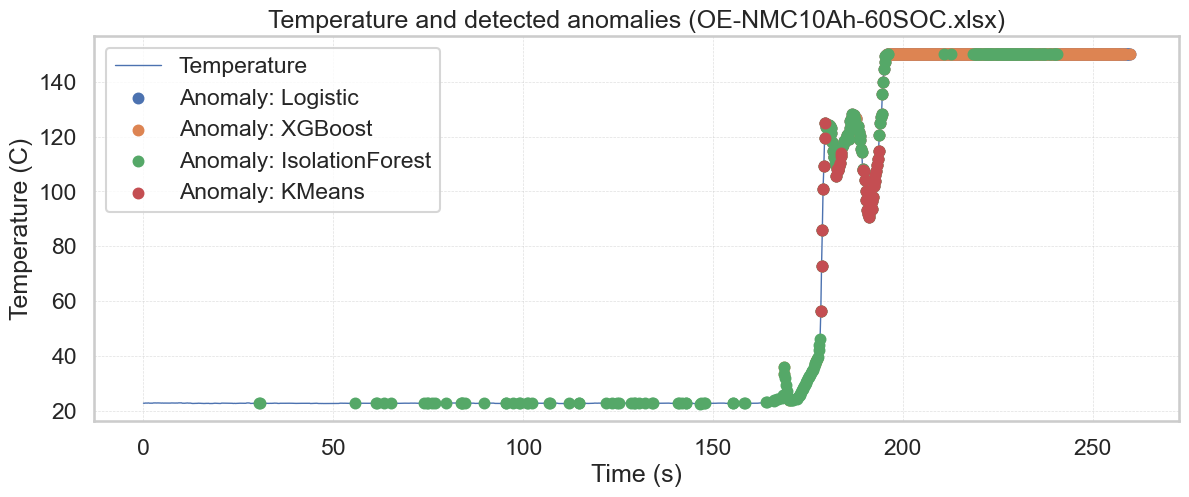

Plotting file: Soteria-control-5100mAh-50SOC.xlsx


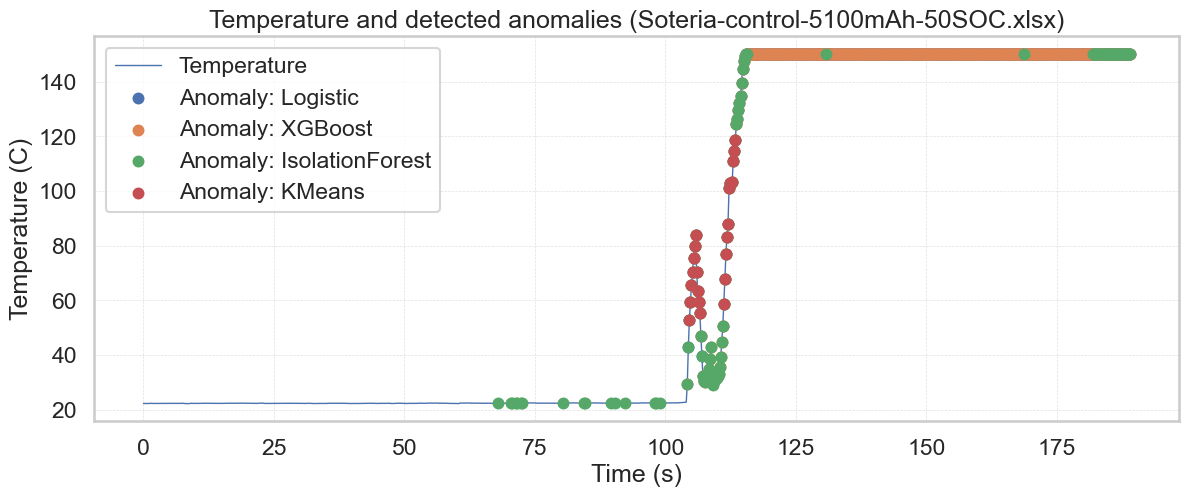

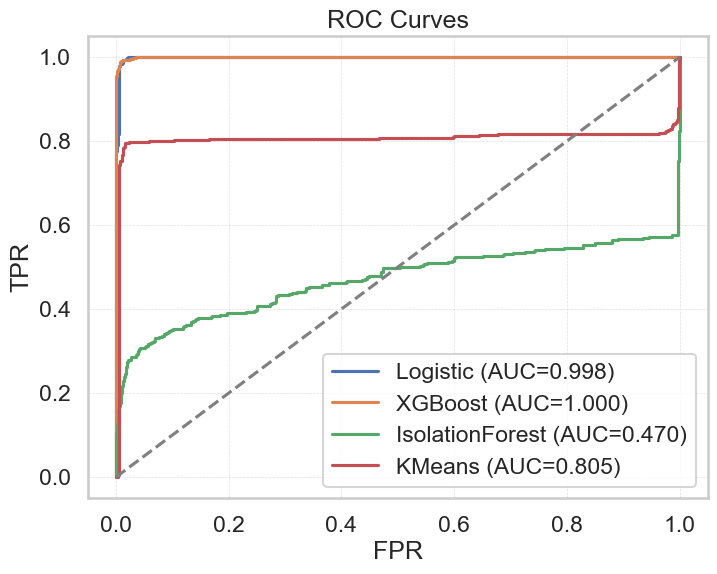

In [120]:
# Updated snippet 7 - plotting functions (robust & ready-to-drop)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def _align_pred_to_df(pred, df_sub, df_full):
    """
    Return a 1D numpy array of preds aligned to df_sub rows.
    pred may be:
      - ndarray/list length == len(df_full)  -> we select entries corresponding to df_sub rows
      - ndarray/list length == len(df_sub)   -> used directly (assumed already aligned)
      - pd.Series with an index matching either df_full or df_sub -> aligned accordingly
    If alignment fails, returns zeros.
    """
    # convert pandas Series to ndarray with index awareness
    if isinstance(pred, pd.Series):
        # prefer indices matching df_sub
        if pred.index.equals(df_sub.index):
            return pred.values.astype(int)
        if pred.index.equals(df_full.index):
            return pred.loc[df_sub.index].fillna(0).astype(int).values
        # try reindex
        try:
            return pred.reindex(df_sub.index, fill_value=0).astype(int).values
        except Exception:
            return np.zeros(len(df_sub), dtype=int)

    # for list / ndarray
    pred_arr = np.asarray(pred)
    if pred_arr.ndim != 1:
        pred_arr = pred_arr.ravel()

    if pred_arr.size == len(df_sub):
        return pred_arr.astype(int)
    if pred_arr.size == len(df_full):
        # map df_sub rows to df_full positions
        # get_indexer returns positions in df_full for each df_sub index
        positions = df_full.index.get_indexer(df_sub.index)
        # positions == -1 means index not found -> treat as 0
        valid = positions >= 0
        out = np.zeros(len(df_sub), dtype=int)
        if valid.any():
            out[valid] = pred_arr[positions[valid]].astype(int)
        return out
    # fallback
    return np.zeros(len(df_sub), dtype=int)


def plot_time_series_with_anomalies(df_original, preds_dict, time_col=COL_TIME, temp_col='temp',
                                   file_field='_source_file', file_to_plot=None, figsize=(14,5)):
    """
    df_original: full test DataFrame (with index)
    preds_dict: mapping name -> 1D array/Series of binary predictions aligned with df_original rows,
                or already aligned to the subset passed via file_to_plot.
    file_to_plot: if given, only that file's rows are plotted (useful to inspect per-file)
    """
    df_full = df_original.copy()
    if file_to_plot:
        df = df_full[df_full[file_field] == file_to_plot].copy()
    else:
        df = df_full.copy()

    if df.empty:
        print(f"No data to plot for file: {file_to_plot}")
        return

    t = df[time_col]
    plt.figure(figsize=figsize)
    plt.plot(t, df[temp_col], label='Temperature', linewidth=1)

    # overlay predictions (align each pred vector to df subset)
    for name, pred in preds_dict.items():
        pred_sub = _align_pred_to_df(pred, df, df_full)
        # indices within df where pred_sub == 1
        anom_mask = pred_sub == 1
        if anom_mask.any():
            plt.scatter(df.loc[anom_mask, time_col], df.loc[anom_mask, temp_col],
                        label=f"Anomaly: {name}", s=50, zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (C)')
    plt.legend()
    title_file = file_to_plot if file_to_plot else 'all files'
    plt.title(f"Temperature and detected anomalies ({title_file})")
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    plt.show()


def plot_roc_curves(y_true, scores_dict):
    """
    y_true: 1D array-like ground-truth labels
    scores_dict: mapping name -> score array aligned with y_true
    """
    y_true_arr = np.asarray(y_true).ravel()
    plt.figure(figsize=(8,6))
    for name, score in scores_dict.items():
        s_arr = np.asarray(score).ravel()
        if s_arr.size != y_true_arr.size:
            print(f"Skipping ROC for {name}: length mismatch (scores={s_arr.size}, y_true={y_true_arr.size})")
            continue
        # guard against constant scores
        if np.allclose(s_arr, s_arr[0]):
            print(f"Skipping ROC for {name}: constant score values (AUC undefined)")
            continue
        fpr, tpr, _ = roc_curve(y_true_arr, s_arr)
        auc_val = roc_auc_score(y_true_arr, s_arr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    plt.show()


# ----------------------------
# Build preds and scores dicts for plotting (example; ensure these variables exist)
# ----------------------------
preds_dict = {
    "Logistic": y_log_pred,
    "XGBoost": y_xgb_pred,
    "IsolationForest": iso_pred,
    "KMeans": k_anom_pred
}

scores_dict = {
    "Logistic": y_log_score,
    "XGBoost": y_xgb_score,
    "IsolationForest": iso_scores,
    "KMeans": -distances  # higher=more anomalous
}
# ---- Ensure scores are computed BEFORE thresholding/pred creation ----
# y_log_score must be available before you threshold y_log_pred
# (if not, compute it now)
# y_log_score = log_model.predict_proba(X_test)[:, 1]  # if needed

# choose test_df (prefer explicit variable names)
if 'df_test' in globals():
    test_df = df_test.copy()
elif 'dftt' in globals():
    test_df = dftt.copy()
else:
    raise NameError("No test DataFrame found as 'df_test' or 'dftt' in the current namespace.")

# Make sure test_df index is the same order as your y_test / score arrays.
# If y_test is a pandas Series with same index, use it. Otherwise assume arrays are in the same order as test_df rows.

# ---- Build preds and scores dicts as pd.Series aligned to test_df.index ----
preds_dict = {
    "Logistic": pd.Series(y_log_pred, index=test_df.index),
    "XGBoost": pd.Series(y_xgb_pred, index=test_df.index),
    "IsolationForest": pd.Series(iso_pred, index=test_df.index),
    "KMeans": pd.Series(k_anom_pred, index=test_df.index)
}

scores_dict = {
    "Logistic": pd.Series(y_log_score, index=test_df.index),
    "XGBoost": pd.Series(y_xgb_score, index=test_df.index),
    "IsolationForest": pd.Series(iso_scores, index=test_df.index),
    "KMeans": pd.Series(-distances, index=test_df.index)  # higher = more anomalous
}

# ---- Per-file plotting (uses aligned series) ----
for sample_file in test_df['_source_file'].unique():
    print(f"Plotting file: {sample_file}")
    plot_time_series_with_anomalies(test_df, preds_dict, file_to_plot=sample_file)

# ---- ROC plotting: ensure y_true aligns with scores ----
# Prefer an explicit y_true derived from test_df so alignment is guaranteed
if 'label_final' in test_df.columns:
    y_true = test_df['label_final'].astype(int).values
elif 'y_test' in globals():
    y_true = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)
elif 'yte' in globals():
    y_true = yte.values if hasattr(yte, "values") else np.asarray(yte)
else:
    raise NameError("No label vector found; provide 'label_final' column in test_df or y_test/yte variables.")

# Convert scores_dict values back to arrays aligned with y_true
scores_for_roc = {}
for name, s in scores_dict.items():
    s_arr = np.asarray(s.reindex(test_df.index).values)  # ensure alignment
    if s_arr.size != y_true.size:
        print(f"Skipping {name} for ROC: length mismatch (scores={s_arr.size}, y_true={y_true.size})")
        continue
    scores_for_roc[name] = s_arr

# Finally plot ROC curves using the aligned scores
plot_roc_curves(y_true, scores_for_roc)


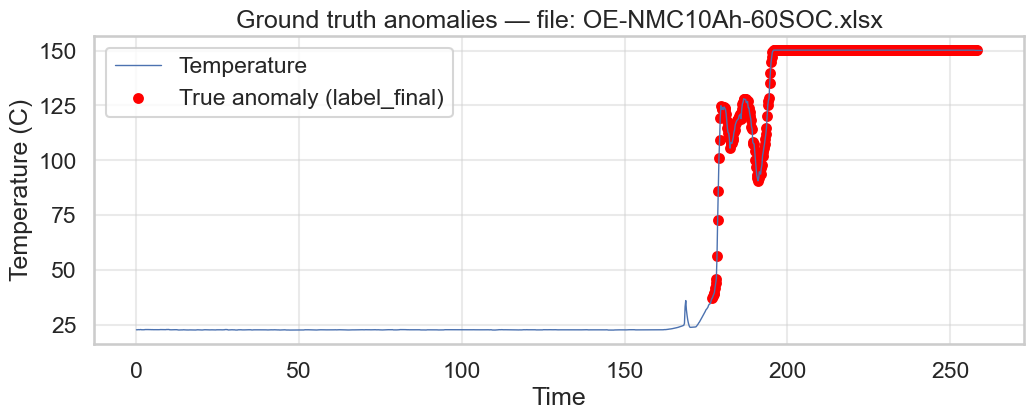

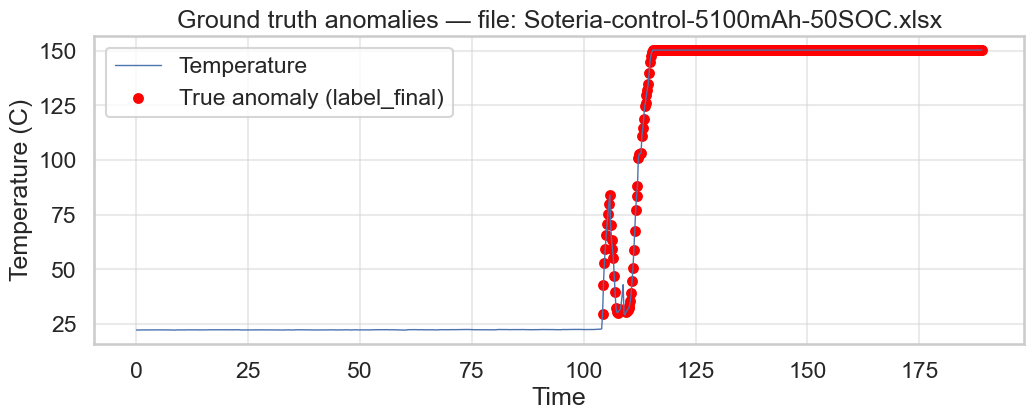

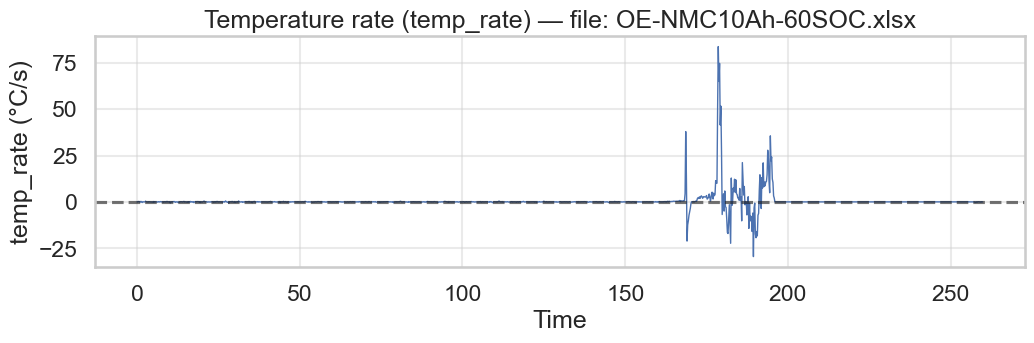

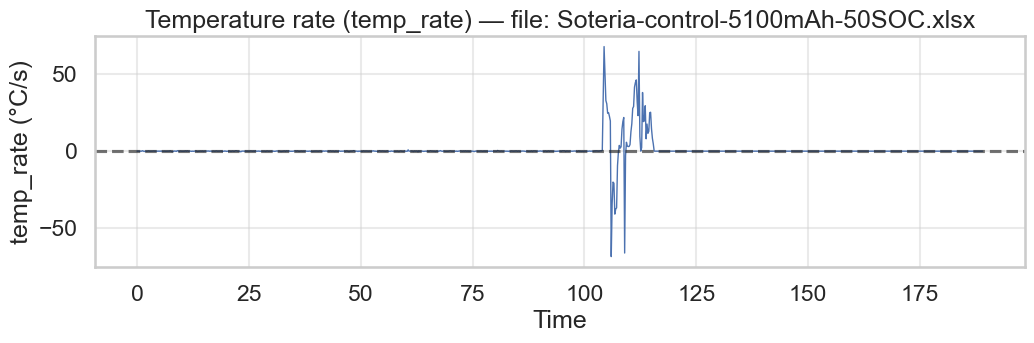

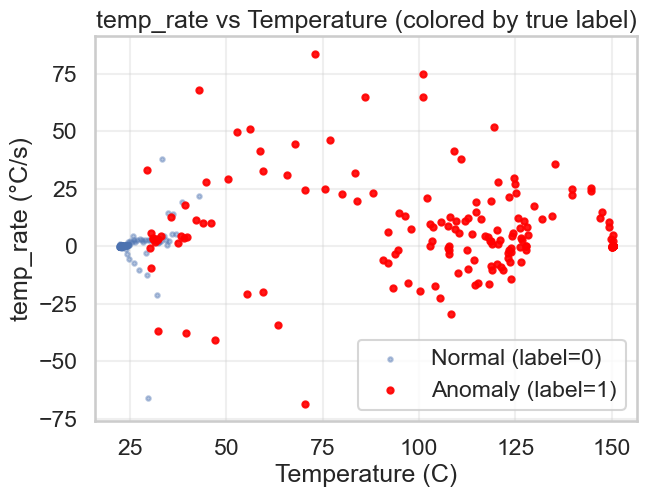

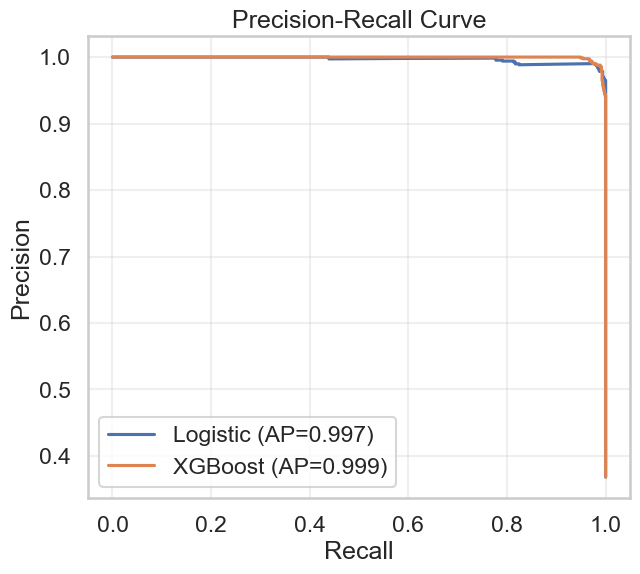

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- Helper: find test dataframe and aligned label vector ---
if 'df_test' in globals():
    test_df = df_test.copy()
elif 'dftt' in globals():
    test_df = dftt.copy()
else:
    raise NameError("No test dataframe found as 'df_test' or 'dftt'.")

# prefer label_final column in test_df
if 'label_final' in test_df.columns:
    y_true_series = test_df['label_final'].astype(int)
elif 'y_test' in globals():
    y_true_series = pd.Series(y_test, index=test_df.index)
elif 'yte' in globals():
    y_true_series = pd.Series(yte, index=test_df.index)
else:
    raise NameError("No labels found: add 'label_final' to test_df or provide y_test/yte.")

# small alignment helper for score arrays
def scores_to_series(score_arr, test_df):
    if score_arr is None:
        return None
    s = np.asarray(score_arr).ravel()
    if s.size == len(test_df):
        return pd.Series(s, index=test_df.index)
    # if shape mismatch, try to preserve order if possible
    try:
        return pd.Series(s, index=test_df.index[:s.size])
    except Exception:
        return pd.Series(np.zeros(len(test_df)), index=test_df.index)

# create series for logistic/xgb scores if available
log_score_ser = scores_to_series(globals().get('y_log_score', None), test_df)
xgb_score_ser = scores_to_series(globals().get('y_xgb_score', None), test_df)

# -----------------------------
# 1) Ground-truth: temperature + true labels (per file)
# -----------------------------
for f in test_df['_source_file'].unique():
    sub = test_df[test_df['_source_file'] == f]
    if sub.empty:
        continue
    plt.figure(figsize=(12,4))
    plt.plot(sub[COL_TIME], sub[COL_TEMP], label='Temperature', linewidth=1)
    lab_mask = sub['label_final'].astype(int) == 1
    if lab_mask.any():
        plt.scatter(sub.loc[lab_mask, COL_TIME], sub.loc[lab_mask, COL_TEMP],
                    color='red', s=40, label='True anomaly (label_final)')
    plt.xlabel('Time')
    plt.ylabel('Temperature (C)')
    plt.title(f"Ground truth anomalies — file: {f}")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

# -----------------------------
# 2) temp_rate vs time (per file)
# -----------------------------
if 'temp_rate' not in test_df.columns:
    print("Warning: 'temp_rate' column not found in test_df — skip temp_rate plot.")
else:
    for f in test_df['_source_file'].unique():
        sub = test_df[test_df['_source_file'] == f]
        if sub.empty:
            continue
        plt.figure(figsize=(12,3))
        plt.plot(sub[COL_TIME], sub['temp_rate'], label='temp_rate (°C/s)', linewidth=1)
        plt.axhline(0, color='k', linestyle='--', alpha=0.6)
        plt.xlabel('Time')
        plt.ylabel('temp_rate (°C/s)')
        plt.title(f"Temperature rate (temp_rate) — file: {f}")
        plt.grid(alpha=0.4)
        plt.show()

# -----------------------------
# 3) Scatter: temp_rate vs temp colored by label_final (all data)
# -----------------------------
if 'temp_rate' in test_df.columns:
    plt.figure(figsize=(7,5))
    lbl = test_df['label_final'].astype(int)
    low = test_df[lbl==0]
    high = test_df[lbl==1]
    plt.scatter(low[COL_TEMP], low['temp_rate'], s=10, alpha=0.4, label='Normal (label=0)')
    if not high.empty:
        plt.scatter(high[COL_TEMP], high['temp_rate'], s=20, alpha=0.9, color='red', label='Anomaly (label=1)')
    plt.xlabel('Temperature (C)')
    plt.ylabel('temp_rate (°C/s)')
    plt.title('temp_rate vs Temperature (colored by true label)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Skipping scatter (temp vs temp_rate): 'temp_rate' column missing.")

# -----------------------------
# 4) Precision-Recall curve(s) — Logistic and XGBoost if available
# -----------------------------
plt.figure(figsize=(7,6))
plotted = False

if log_score_ser is not None:
    y_true = y_true_series.loc[log_score_ser.index].values
    prec, rec, thr = precision_recall_curve(y_true, log_score_ser.values)
    ap = average_precision_score(y_true, log_score_ser.values)
    plt.plot(rec, prec, label=f'Logistic (AP={ap:.3f})')
    plotted = True

if xgb_score_ser is not None:
    y_true = y_true_series.loc[xgb_score_ser.index].values
    prec2, rec2, thr2 = precision_recall_curve(y_true, xgb_score_ser.values)
    ap2 = average_precision_score(y_true, xgb_score_ser.values)
    plt.plot(rec2, prec2, label=f'XGBoost (AP={ap2:.3f})')
    plotted = True

if not plotted:
    print("No score arrays found for Logistic/XGBoost — skipping PR curve.")
else:
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


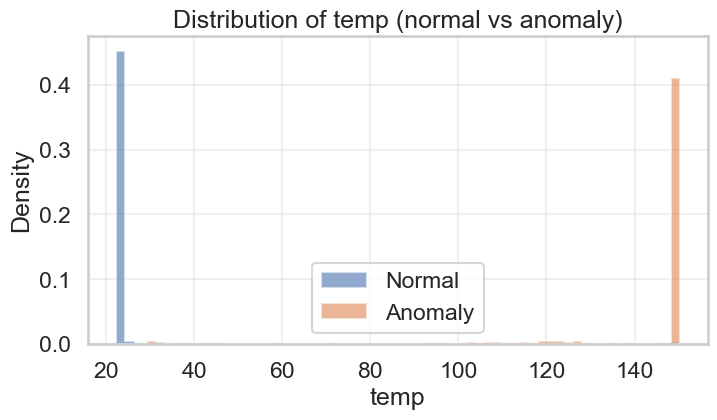

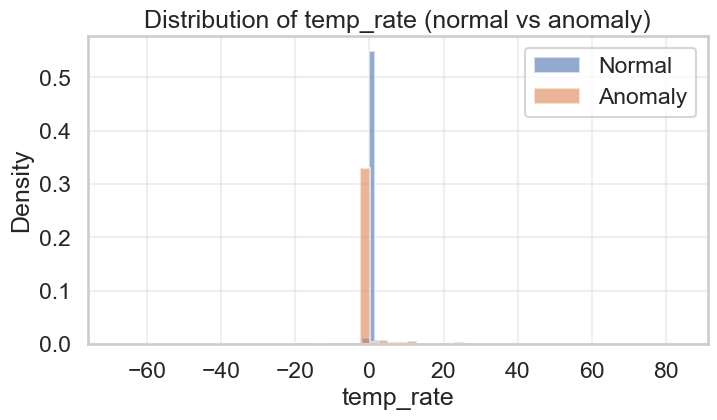

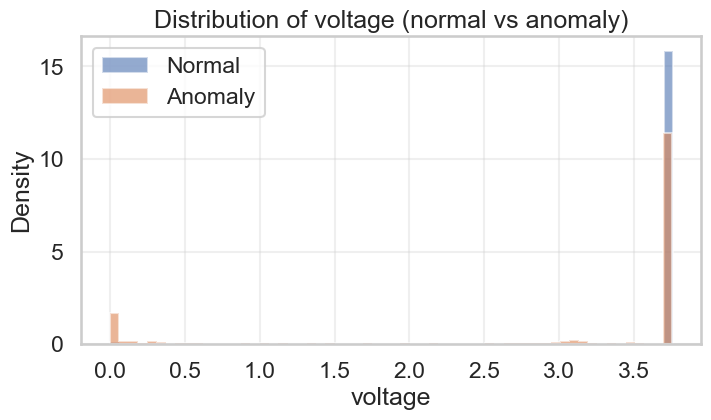

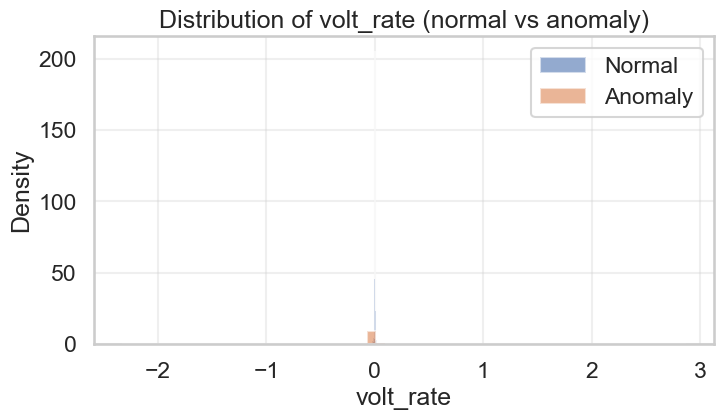

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# which df to use
df = dftt.copy() if 'dftt' in globals() else (df_test.copy() if 'df_test' in globals() else None)
if df is None:
    raise NameError("No test dataframe (dftt or df_test) found.")

vars_to_plot = ['temp', 'temp_rate', 'voltage', 'volt_rate']
for v in vars_to_plot:
    if v not in df.columns:
        continue
    plt.figure(figsize=(8,4))
    data0 = df.loc[df['label_final']==0, v].dropna()
    data1 = df.loc[df['label_final']==1, v].dropna()
    # histograms + KDE-like smooth via density hist
    plt.hist(data0, bins=60, density=True, alpha=0.6, label='Normal', histtype='stepfilled')
    if len(data1)>0:
        plt.hist(data1, bins=60, density=True, alpha=0.6, label='Anomaly', histtype='stepfilled')
    plt.title(f"Distribution of {v} (normal vs anomaly)")
    plt.xlabel(v)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


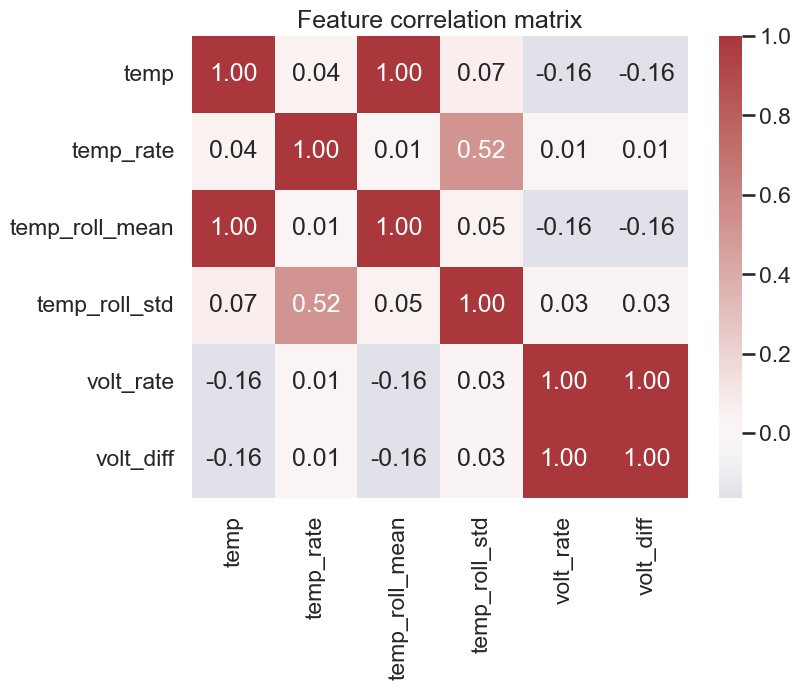

In [123]:
# ---- Auto-detect test DataFrame ----
if 'df_test' in globals():
    test_df = df_test.copy()
elif 'dftt' in globals():
    test_df = dftt.copy()
elif 'artifacts' in globals() and 'df_test' in artifacts:
    test_df = artifacts['df_test'].copy()
else:
    raise NameError("No test DataFrame found. Expected df_test or dftt or artifacts['df_test'].")

# ---- Correlation Heatmap ----
import seaborn as sns
plt.figure(figsize=(8,6))

feature_candidates = ['temp','temp_rate','temp_roll_mean','temp_roll_std','volt_rate','volt_diff']
feat_list = [c for c in feature_candidates if c in test_df.columns]

if not feat_list:
    raise RuntimeError(
        f"No feature columns found. Available: {list(test_df.columns)}"
    )

corr = test_df[feat_list].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Feature correlation matrix")
plt.show()


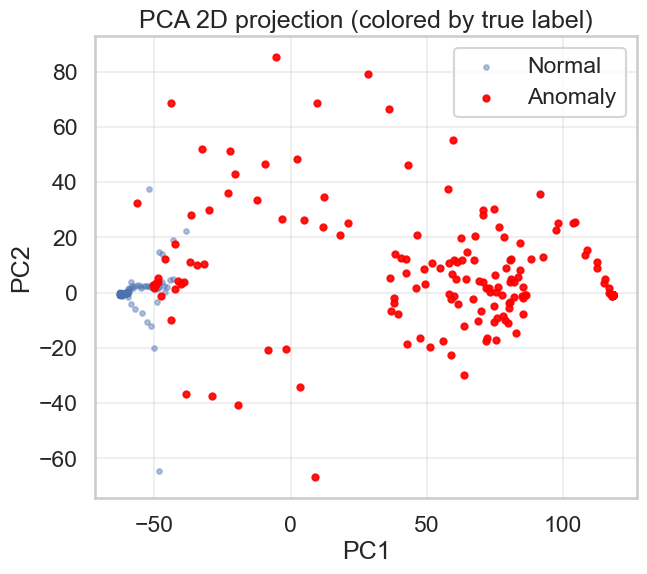

In [124]:
# --- Auto-detect test DataFrame ---
if 'df_test' in globals():
    test_df = df_test.copy()
elif 'dftt' in globals():
    test_df = dftt.copy()
elif 'artifacts' in globals() and 'df_test' in artifacts:
    test_df = artifacts['df_test'].copy()
else:
    raise NameError("No test DataFrame found. Expected df_test or dftt or artifacts['df_test'].")

# --- Select feature columns ---
if 'FEATURES' in globals():
    feat_list = [f for f in FEATURES if f in test_df.columns]
else:
    feat_list = [c for c in test_df.columns if c in ['temp','temp_rate','voltage','volt_rate']]

if not feat_list:
    raise RuntimeError(f"No PCA features found in test dataframe. Available: {list(test_df.columns)}")

# --- PCA ---
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X = test_df[feat_list].fillna(0).values
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)

# --- Labels ---
lbl = test_df['label_final'].astype(int).values

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(Z[lbl==0, 0], Z[lbl==0, 1], s=12, alpha=0.4, label='Normal')
if (lbl==1).any():
    plt.scatter(Z[lbl==1, 0], Z[lbl==1, 1], s=20, alpha=0.9, color='red', label='Anomaly')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D projection (colored by true label)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [125]:
# Diagnostic cell to find out why "no change" occurred
import inspect
import numpy as np
import pandas as pd

# 1) confirm functions exist
print("Functions present in namespace:")
print("preprocess_and_label:", 'preprocess_and_label' in globals())
print("preprocess_and_label_improved:", 'preprocess_and_label_improved' in globals())

# optional: print id / first lines of each function to ensure replaced version is loaded
if 'preprocess_and_label' in globals():
    try:
        print("\n--- preprocess_and_label source snippet ---")
        print("\n".join(inspect.getsource(preprocess_and_label).splitlines()[:20]))
    except Exception:
        pass
if 'preprocess_and_label_improved' in globals():
    try:
        print("\n--- preprocess_and_label_improved source snippet ---")
        print("\n".join(inspect.getsource(preprocess_and_label_improved).splitlines()[:20]))
    except Exception:
        pass

# 2) pick a small sample test file to inspect
if 'dftt' in globals():
    test_df = dftt.copy()
elif 'df_test' in globals():
    test_df = df_test.copy()
elif 'artifacts' in globals() and 'df_test' in artifacts:
    test_df = artifacts['df_test'].copy()
else:
    raise RuntimeError("No test dataframe found as dftt/df_test/artifacts['df_test'].")

# Choose one source file that we saw earlier (first one)
file0 = test_df['_source_file'].unique()[0]
print("\nInspecting file:", file0)

sample_df = test_df[test_df['_source_file'] == file0].copy().reset_index(drop=True)

# 3) run old labeler if exists (safe)
df_old_lab = None
try:
    if 'preprocess_and_label' in globals():
        # if original expects whole-dataset, pass sample with _source_file set
        df_old_lab = preprocess_and_label(sample_df, LABEL_PARAMS).reset_index(drop=True)
        print("Old labeler produced positives:", int(df_old_lab['label_final'].sum()))
except Exception as e:
    print("Old labeler failed:", e)

# 4) run improved labeler
df_new_lab = None
try:
    # try with no params first
    if 'preprocess_and_label_improved' in globals():
        df_new_lab = preprocess_and_label_improved(sample_df, None).reset_index(drop=True)
        print("Improved labeler (default params) produced positives:", int(df_new_lab['label_final'].sum()))
    else:
        print("preprocess_and_label_improved not found in globals()")
except Exception as e:
    print("Improved labeler failed:", e)

# 5) show differences if both present
if df_old_lab is not None and df_new_lab is not None:
    # align
    diff_mask = df_old_lab['label_final'].values != df_new_lab['label_final'].values
    n_diff = int(diff_mask.sum())
    print(f"\nNumber of differing rows between old/new: {n_diff} / {len(df_old_lab)}")
    if n_diff > 0:
        print("\nExamples where they differ (first 10):")
        display(
            pd.concat([
                df_old_lab.loc[diff_mask, ['temp','temp_rate','label_final']].rename(columns={'label_final':'old_label'}).head(10),
                df_new_lab.loc[diff_mask, ['label_final']].rename(columns={'label_final':'new_label'}).head(10)
            ], axis=1)
        )

# 6) Stats for flagged points (new label)
if df_new_lab is not None:
    lbl_idx = df_new_lab['label_final'] == 1
    print("\nNew label stats (flagged rows):")
    if lbl_idx.sum() == 0:
        print(" No flagged rows by improved labeler.")
    else:
        print(" Count flagged:", int(lbl_idx.sum()))
        print(" Temp min/mean/max:", df_new_lab.loc[lbl_idx,'temp'].min(), df_new_lab.loc[lbl_idx,'temp'].mean(), df_new_lab.loc[lbl_idx,'temp'].max())
        print(" temp_rate min/mean/max:", df_new_lab.loc[lbl_idx,'temp_rate'].min(), df_new_lab.loc[lbl_idx,'temp_rate'].mean(), df_new_lab.loc[lbl_idx,'temp_rate'].max())

# 7) If improved produced too many flags near low temp, try a stricter param set and show result
stricter = {
    "rolling_window": 5,
    "rate_thresh_abs": 0.6,
    "z_k": 4.0,
    "min_temp_C": 45.0,         # require temp >= 45C
    "min_increase_C": 7.0,      # require future rise >= 7C
    "lookahead_samples": 6,
    "min_consecutive": 4,
    "expand_forward": 8
}
print("\nTrying a stricter param set (likely to reduce low-temp false positives):")
try:
    df_new_strict = preprocess_and_label_improved(sample_df, stricter).reset_index(drop=True)
    print("Strict improved positives:", int(df_new_strict['label_final'].sum()))
    if df_new_strict['label_final'].sum() < (df_new_lab['label_final'].sum() if df_new_lab is not None else 1e9):
        print("Strict params reduced positives compared to default improved.")
    # show first few flagged rows in strict version
    if int(df_new_strict['label_final'].sum())>0:
        display(df_new_strict[df_new_strict['label_final']==1][['temp','temp_rate']].head(10))
except Exception as e:
    print("Strict run failed:", e)

# 8) Final hints printed (no further action)
print("\nIf (a) preprocess_and_label_improved was not called, re-run the cell that defines it and then re-run pipeline.\nIf (b) improved labels are still too many, tune 'min_temp_C' upward and 'min_increase_C' upward, or raise 'min_consecutive'.\nIf (c) labels are unchanged but you expected change, ensure you are calling preprocess_and_label_improved when creating df_train/df_test.")


Functions present in namespace:
preprocess_and_label: True
preprocess_and_label_improved: True

--- preprocess_and_label source snippet ---
def preprocess_and_label(df, label_params=None):
    # label_params: dict with keys:
    #  - window_s: seconds used for rolling windows (applies to index-based window later)
    #  - rate_thresh_abs: absolute threshold for temp_rate (°C/s)
    #  - z_k: factor for mean+z_k*std threshold
    #  - min_increase_C: absolute temp increase threshold in a short interval (optional)
    if label_params is None:
        label_params = {
            "rate_thresh_abs": 0.5,   # °C/s (tweak depending on sampling)
            "z_k": 3.0,               # multiples of std above mean
            "rolling_window": 5       # in number of samples for rolling stats (small by default)
        }

    df = df.copy()
    # ensure time sorted per file
    if '_source_file' in df.columns:
        df.sort_values(['_source_file', COL_TIME], inplace=True)
    else:
        df.

,temp,temp_rate,old_label,new_label
0,22.755920,NaN,1,0
1,22.749537,-0.031917,1,0
2,22.787318,0.188907,1,0
3,22.826435,0.195586,1,0
4,22.811318,-0.075586,1,0
48,22.875500,0.024852,1,0
49,22.861192,-0.071541,1,0
50,22.888739,0.137737,1,0
51,22.772157,-0.582912,1,0
52,22.758534,-0.068113,1,0



New label stats (flagged rows):
 Count flagged: 407
 Temp min/mean/max: 37.30939367346942 140.77238689544265 150.2427
 temp_rate min/mean/max: -29.486132618762014 1.389128622863057 83.72797597243408

Trying a stricter param set (likely to reduce low-temp false positives):
Strict improved positives: 406
Strict params reduced positives compared to default improved.


,temp,temp_rate
886,38.238031,4.643187
887,38.907611,3.347898
888,39.715974,4.041817
889,42.008371,11.461984
890,44.027615,10.096222
891,46.044029,10.082066
892,56.226608,50.912897
893,72.972203,83.727976
894,85.959631,64.937138
895,100.892651,74.665098



If (a) preprocess_and_label_improved was not called, re-run the cell that defines it and then re-run pipeline.
If (b) improved labels are still too many, tune 'min_temp_C' upward and 'min_increase_C' upward, or raise 'min_consecutive'.
If (c) labels are unchanged but you expected change, ensure you are calling preprocess_and_label_improved when creating df_train/df_test.
